# 05. V1 Retrieval 패턴 & Hybrid RAG

> 리트리버 자체에도 디자인이 필요해요. 2-Step / Agentic / Hybrid 세 가지 retrieval 패턴과 쿼리 강화 · MMR 같은 검색 품질 트릭을 묶어 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **2-Step RAG** 패턴으로 검색과 생성을 분리하여 LangGraph 노드로 구현할 수 있어요
2. **Agentic RAG** 패턴으로 `create_agent`와 `@tool` 데코레이터를 활용한 도구 기반 검색 에이전트를 만들 수 있어요
3. **Hybrid RAG** 패턴으로 쿼리 강화(Query Enhancement)와 검증 루프를 통해 다중 전략 검색을 구현할 수 있어요
4. **FAISS** 벡터스토어와 `as_retriever()`로 다양한 검색 파라미터를 조정할 수 있어요
5. 메타데이터 필터링으로 소스, 페이지 범위별 검색 범위를 제한할 수 있어요

## 사전 지식

- 이전 노트북 `04-Adaptive-RAG.ipynb`에서 배운 라우팅 + 평가 기반 RAG 패턴
- `FAISS.from_documents()`, `OpenAIEmbeddings`, `RecursiveCharacterTextSplitter` 기본 사용법
- LangGraph `StateGraph`, 조건부 엣지, `create_agent` 기본 개념

## RAG 패턴 비교

이 노트북에서는 세 가지 Retrieval 패턴을 비교하며 배워요. 각각의 장단점과 적합한 사용 시나리오가 달라요.

> 🔑 **핵심 개념**: 이전 노트북들(01-04)에서는 "검색 결과를 어떻게 검증하고 보강할까?"에 집중했어요. 이 노트북에서는 한 걸음 더 나아가 "검색 자체를 어떻게 더 잘할까?"를 다뤄요. 같은 FAISS 인덱스라도 **어떻게 질문하느냐**에 따라 검색 결과가 완전히 달라져요.

### 세 가지 패턴 비교

| 패턴 | 검색 전략 | 비유 | 적합한 시나리오 |
|------|----------|------|----------------|
| **2-Step RAG** | 단일 벡터 검색 | 도서관에서 제목 하나로 검색 | 문서가 잘 정리된 경우 |
| **Agentic RAG** | 에이전트가 도구 결정 | 사서에게 질문하면 알아서 찾아줌 | 복잡한 질문, 다중 소스 |
| **Hybrid RAG** | 쿼리 강화 + 다중 검색 | 같은 질문을 여러 방식으로 검색 | 정확도가 중요한 경우 |

> 🎯 **강의 포인트**: 세 패턴 모두 같은 FAISS 인덱스를 사용하지만, **어떻게 검색하고 검증하는지**가 달라요. 2-Step은 "한 번 묻고 끝", Agentic은 "필요할 때만 묻기", Hybrid는 "같은 질문을 여러 각도로 묻기"예요.

### 전체 아키텍처

```mermaid
flowchart LR
    subgraph 공통 인프라
        D[(FAISS<br/>벡터스토어)] 
        E[OpenAI<br/>Embeddings]
    end

    subgraph 패턴1[2-Step RAG]
        A1[질문] --> B1[retrieve<br/>검색]
        B1 --> C1[generate<br/>생성]
    end

    subgraph 패턴2[Agentic RAG]
        A2[질문] --> B2[agent<br/>도구 결정]
        B2 -- 검색필요 --> C2[tool<br/>실행]
        C2 --> B2
        B2 -- 완료 --> D2[최종답변]
    end

    subgraph 패턴3[Hybrid RAG]
        A3[질문] --> B3[query<br/>enhancement]
        B3 --> C3[multi<br/>retrieve]
        C3 --> E3{검증}
        E3 -- 불충분 --> B3
        E3 -- 충분 --> F3[generate]
    end

    D --> B1
    D --> C2
    D --> C3

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A1,A2,A3 input
    class B1,B2,C2,B3,C3,E3 process
    class C1,D2,F3 output
    class D,E storage
```

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 설정
# ---------------------------------------------------
# dotenv: .env 파일에서 API 키를 로드해요
from dotenv import load_dotenv

# OPENAI_API_KEY, TAVILY_API_KEY 등을 .env에서 불러와요
load_dotenv(override=True)

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# LangSmith를 사용하면 그래프 실행을 시각적으로 추적할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-RAG-Retrieval"

## 2. 공통 인프라: FAISS 벡터스토어 구성

세 가지 패턴 모두 동일한 FAISS 인덱스를 사용해요. PDF를 로드하고 청크로 분할한 뒤 임베딩하여 검색 가능한 벡터스토어를 만들어요.

> 💡 **실무 팁**: `chunk_size`와 `chunk_overlap`은 검색 품질에 큰 영향을 미쳐요. 너무 작으면 문맥이 잘리고, 너무 크면 관련 없는 내용이 섞여요. 일반적으로 500~1000자 크기에 10~20% 오버랩이 좋은 출발점이에요.

**실습 문서**: 소프트웨어정책연구소(SPRi) AI Brief 2023년 12월호

In [3]:
# ---------------------------------------------------
# PDF 로드 및 청킹
# ---------------------------------------------------
# PyPDFLoader: PDF를 페이지 단위로 로드해요
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# PDF 파일 경로 (data 디렉토리에 저장해요)
PDF_PATH = "data/SPRI_AI_Brief_2023년12월호_F.pdf"

# 페이지 단위로 문서 로드
loader = PyPDFLoader(PDF_PATH)
pages = loader.load()
print(f"총 {len(pages)}페이지 로드 완료")

# 청크로 분할
# chunk_size: 한 청크의 최대 글자 수
# chunk_overlap: 청크 간 겹치는 글자 수 (문맥 유지)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
)
docs = splitter.split_documents(pages)
print(f"총 {len(docs)}개 청크 생성")

# 첫 번째 청크 미리보기
print(f"\n첫 번째 청크 미리보기:")
print(f"내용: {docs[0].page_content[:200]}...")
print(f"메타데이터: {docs[0].metadata}")

총 23페이지 로드 완료
총 85개 청크 생성

첫 번째 청크 미리보기:
내용: 2023년 12월호...
메타데이터: {'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2018 10.0.0.13462', 'creationdate': '2023-12-08T13:28:38+09:00', 'author': 'dj', 'moddate': '2023-12-08T13:28:38+09:00', 'pdfversion': '1.4', 'source': 'data/SPRI_AI_Brief_2023년12월호_F.pdf', 'total_pages': 23, 'page': 0, 'page_label': '1'}


In [4]:
# ---------------------------------------------------
# FAISS 벡터스토어 생성
# ---------------------------------------------------
# OpenAIEmbeddings: 텍스트를 고차원 벡터로 변환해요
# FAISS: 빠른 근사 최근접 이웃 검색(ANN)을 지원해요
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# text-embedding-3-small: 비용 효율적인 임베딩 모델
# 더 높은 품질: "text-embedding-3-large"
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# FAISS 인덱스 생성 (청크 → 벡터 변환 및 저장)
vectorstore = FAISS.from_documents(docs, embeddings)
print(f"FAISS 인덱스 생성 완료: {vectorstore.index.ntotal}개 벡터 저장됨")

FAISS 인덱스 생성 완료: 85개 벡터 저장됨


In [5]:
# ---------------------------------------------------
# as_retriever()로 검색기 생성
# ---------------------------------------------------
# as_retriever(): 벡터스토어를 검색 인터페이스로 변환해요
# search_type: 검색 방법 선택
#   - "similarity": 유사도 기반 (기본값)
#   - "mmr": 최대 한계 관련성 (다양성 보장)
# search_kwargs: 검색 파라미터 설정

# 기본 retriever (유사도 기반, 상위 4개)
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}  # 상위 4개 문서 반환
)

# 테스트 검색
test_query = "삼성전자 생성형 AI"
test_results = retriever.invoke(test_query)
print(f"검색어: '{test_query}'")
print(f"검색 결과: {len(test_results)}개")
for i, doc in enumerate(test_results[:2]):
    print(f"\n[결과 {i+1}] 페이지 {doc.metadata.get('page', 0)+1}")
    print(f"{doc.page_content[:150]}...")

검색어: '삼성전자 생성형 AI'
검색 결과: 4개

[결과 1] 페이지 13
다양한 모델로 구성되며, 메일 작성, 문서 요약, 번역 업무의 처리를 지원∙코드 모델 기반의 AI 코딩 어시스턴트 ‘코드아이(code.i)’는 대화형 인터페이스로 서비스를 제공하며 사내 소프트웨어 개발에 최적화∙이미지 모델은 창의적인 이미지를 생성하고 기존 이미지를 원...

[결과 2] 페이지 13
SPRi AI Brief |  2023-12월호
10
삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개n삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성 AI 모델 ‘삼성 가우스’를 공개n삼성전자는 삼성 가우스를 다양...


In [6]:
# ---------------------------------------------------
# 공통 유틸리티: 문서 포맷팅 함수
# ---------------------------------------------------
# 여러 노드에서 공통으로 사용하는 문서 포맷팅 함수예요

def format_docs(docs):
    """문서 리스트를 프롬프트 입력 형식으로 포맷팅해요."""
    return "\n\n".join(
        f"<document>\n<content>{doc.page_content}</content>\n"
        f"<source>{doc.metadata.get('source', 'unknown')}</source>\n"
        f"<page>{doc.metadata.get('page', 0) + 1}</page>\n</document>"
        for doc in docs
    )


# 유틸리티 함수 준비 완료

In [7]:
# ---------------------------------------------------
# 공통 RAG 체인 구성
# ---------------------------------------------------
# 세 가지 패턴에서 공통으로 사용하는 답변 생성 체인이에요
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 옵션: "anthropic:claude-sonnet-4-5", "ollama:llama3"
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# RAG 프롬프트 템플릿
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant. Answer the question based on the provided context.
If the context doesn't contain enough information, say so clearly.
Always cite your sources by mentioning the document name and page number."""),
    ("human", """Context: {context}

Question: {question}

Answer in Korean:""")
])

# RAG 체인: 프롬프트 → LLM → 텍스트 파서
rag_chain = RAG_PROMPT | llm | StrOutputParser()
# 공통 RAG 체인 준비 완료

---

## 3. 패턴 1: 2-Step RAG

가장 단순하고 직관적인 RAG 패턴이에요. **검색(Retrieve)** 노드와 **생성(Generate)** 노드가 순차적으로 실행되는 선형 파이프라인이에요.

### 2-Step RAG의 흐름

```mermaid
flowchart LR
    A([START]) --> B[retrieve<br>벡터 검색]
    B --> C[generate<br>답변 생성]
    C --> D([END])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef terminal fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A,D terminal
    class B process
    class C output
```

> 🎯 **강의 포인트**: 2-Step RAG의 단순함이 오히려 장점이에요. 디버깅이 쉽고, 각 단계를 독립적으로 테스트할 수 있어요. 기본적인 Q&A 챗봇에는 이 패턴으로 충분한 경우가 많아요.

> ⚠️ **자주 하는 실수**: `question` 키를 `State`에 포함하지 않으면 노드 간 질문 전달이 안 돼요. `messages` 리스트로만 관리하다가 `retrieve` 노드에서 어떤 질문인지 알 수 없게 되는 경우가 자주 발생해요.

In [8]:
# ---------------------------------------------------
# 2-Step RAG: 상태(State) 정의
# ---------------------------------------------------
# TypedDict: 타입 힌트가 있는 딕셔너리로 상태를 정의해요
from typing import Annotated, List
from typing_extensions import TypedDict
from langchain_core.documents import Document


class TwoStepRAGState(TypedDict):
    """2-Step RAG 그래프의 상태 정의예요."""

    question: Annotated[str, "사용자 질문"]         # 검색에 사용할 질문
    documents: Annotated[List, "검색된 문서 리스트"] # retrieve 노드 결과
    generation: Annotated[str, "생성된 최종 답변"]   # generate 노드 결과

In [9]:
# ---------------------------------------------------
# 2-Step RAG: 노드 함수 정의
# ---------------------------------------------------

def twostep_retrieve(state: TwoStepRAGState) -> TwoStepRAGState:
    """벡터 검색으로 관련 문서를 찾는 노드예요."""
    # ==== [2-STEP RAG: RETRIEVE] ====
    question = state["question"]

    # 벡터 유사도 검색 수행
    documents = retriever.invoke(question)
    print(f"  검색된 문서 수: {len(documents)}개")
    return {"documents": documents}


def twostep_generate(state: TwoStepRAGState) -> TwoStepRAGState:
    """검색된 문서를 컨텍스트로 답변을 생성하는 노드예요."""
    # ==== [2-STEP RAG: GENERATE] ====
    question = state["question"]
    documents = state["documents"]

    # 문서 포맷팅 후 RAG 체인 실행
    context = format_docs(documents)
    generation = rag_chain.invoke({"context": context, "question": question})
    return {"generation": generation}

In [10]:
# ---------------------------------------------------
# 2-Step RAG: 그래프 조립 및 컴파일
# ---------------------------------------------------
from langgraph.graph import END, StateGraph, START

# TwoStepRAGState 기반 그래프 초기화
twostep_workflow = StateGraph(TwoStepRAGState)

# 노드 등록
twostep_workflow.add_node("retrieve", twostep_retrieve)
twostep_workflow.add_node("generate", twostep_generate)

# 선형 엣지 연결: START → retrieve → generate → END
twostep_workflow.add_edge(START, "retrieve")
twostep_workflow.add_edge("retrieve", "generate")
twostep_workflow.add_edge("generate", END)

# 컴파일 (체크포인터 없이 단순 실행)
twostep_app = twostep_workflow.compile()
# 2-Step RAG 그래프 컴파일 완료

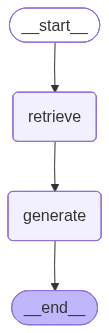

In [11]:
# ---------------------------------------------------
# 2-Step RAG: 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → retrieve → generate → END
# retrieve: FAISS 벡터 유사도 검색으로 상위 k개 문서를 찾아요
# generate: 검색된 문서를 컨텍스트로 RAG 체인을 실행하여 답변을 생성해요
# 선형 구조가 얼마나 단순한지 확인해요
from IPython.display import Image, display

display(Image(twostep_app.get_graph().draw_mermaid_png()))

In [12]:
# ---------------------------------------------------
# 2-Step RAG: 실행 테스트
# ---------------------------------------------------
import uuid
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 테스트 질문
inputs = {"question": "구글이 앤스로픽에 투자한 금액은 얼마인가요?"}

# ============================================================
print(f"질문: {inputs['question']}")
# ============================================================

# 스트리밍 실행으로 각 노드 출력 확인
for chunk in twostep_app.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "documents" in node_output:
            print(f"검색된 문서 수: {len(node_output['documents'])}개")
        if "generation" in node_output:
            print(f"답변:\n{node_output['generation']}")

질문: 구글이 앤스로픽에 투자한 금액은 얼마인가요?
  검색된 문서 수: 4개

--- 노드: retrieve ---
검색된 문서 수: 4개

--- 노드: generate ---
답변:
구글이 앤스로픽에 투자한 금액은 최대 20억 달러입니다. 이 중 5억 달러를 우선 투자하고, 향후 15억 달러를 추가로 투자할 계획입니다 (출처: data/SPRI_AI_Brief_2023년12월호_F.pdf, 페이지 14).


---

## 4. 패턴 2: Agentic RAG

**Agentic RAG**는 `create_agent`로 생성된 에이전트가 검색 도구 사용 여부를 스스로 판단해요. 에이전트는 질문에 따라 도구를 호출하거나 LLM의 내장 지식으로 직접 답변할 수 있어요.

### Agentic RAG의 특징

| 항목 | 설명 |
|------|------|
| **검색 주체** | 에이전트가 자율적으로 결정 |
| **도구 정의** | `@tool` 데코레이터로 Python 함수를 도구로 변환 |
| **도구 선택** | LLM이 질문과 도구 설명을 비교해 선택 |
| **멀티턴** | 한 번에 여러 도구를 순차적으로 호출 가능 |

> 🔑 **핵심 개념**: `@tool` 데코레이터의 **docstring**이 도구 선택의 핵심이에요. LLM이 docstring을 읽고 이 도구를 언제 사용할지 결정해요. 영어로 명확하게 작성하는 것이 중요해요.

### Agentic RAG 흐름

```mermaid
flowchart TD
    A([START]) --> B["agent<br>create_agent"]
    B -- 도구 호출 결정 --> C["tools<br>@tool 실행"]
    C -- 결과 반환 --> B
    B -- 완료 --> D([END])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef terminal fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A,D terminal
    class B,C process
```

> 💡 **실무 팁**: `create_agent`를 사용하면 LangGraph의 내부 루프 로직을 직접 구현하지 않아도 돼요. 도구 목록과 시스템 프롬프트만 정의하면 자동으로 ReAct 패턴(추론 → 행동 → 관찰)을 구현해줘요.

In [13]:
# ---------------------------------------------------
# Agentic RAG: @tool 데코레이터로 검색 도구 생성
# ---------------------------------------------------
# @tool: Python 함수를 LLM이 호출할 수 있는 도구로 변환해요
# docstring은 LLM이 도구 선택 시 참고하는 설명이에요 - 중요!
from langchain.tools import tool


@tool
def search_ai_brief(query: str) -> str:
    """Search the SPRI AI Brief document (December 2023) for information about AI trends,
    companies, investments, and technology research. Use this tool when the user asks
    about AI-related news, company AI investments, or AI research from late 2023.

    Args:
        query: The search query string

    Returns:
        Relevant document excerpts with source information
    """
    # 벡터 검색 수행
    results = retriever.invoke(query)

    # 검색 결과를 문자열로 포맷팅하여 반환
    if not results:
        return "관련 문서를 찾을 수 없습니다."

    return format_docs(results)


@tool
def search_with_page_filter(query: str, start_page: int, end_page: int) -> str:
    """Search the SPRI AI Brief document within a specific page range.
    Use this when you need information from a specific section of the document.

    Args:
        query: The search query string
        start_page: Starting page number (1-based)
        end_page: Ending page number (1-based, inclusive)

    Returns:
        Relevant document excerpts from the specified page range
    """
    # 메타데이터 필터링: 지정된 페이지 범위 내 문서만 검색해요
    # FAISS에서 메타데이터 필터링은 filter 파라미터로 수행해요
    all_results = retriever.invoke(query)

    # 페이지 범위 필터링 (메타데이터 기반)
    # page 메타데이터는 0-based이므로 1을 빼요
    filtered = [
        doc for doc in all_results
        if start_page - 1 <= doc.metadata.get("page", 0) <= end_page - 1
    ]

    if not filtered:
        return f"페이지 {start_page}-{end_page} 범위에서 관련 문서를 찾을 수 없습니다."

    return format_docs(filtered)


# 에이전트가 사용할 도구 목록
agent_tools = [search_ai_brief, search_with_page_filter]
print(f"도구 목록: {[t.name for t in agent_tools]}")

도구 목록: ['search_ai_brief', 'search_with_page_filter']


In [14]:
# ---------------------------------------------------
# Agentic RAG: create_agent로 에이전트 생성
# ---------------------------------------------------
# create_agent: V1 API로 도구 목록과 모델을 받아 에이전트를 생성해요
# 내부적으로 ReAct 패턴(추론-행동-관찰)을 구현해요
from langchain.agents import create_agent

# 에이전트 시스템 프롬프트 (역할과 행동 지침)
AGENT_SYSTEM_PROMPT = """You are a helpful AI research assistant specializing in AI industry trends.
You have access to the SPRI AI Brief document from December 2023.

When answering questions:
1. Use the search tools to find relevant information
2. Always cite the source and page number
3. Answer in Korean
4. If information is not in the document, say so clearly"""

# create_agent로 에이전트 생성
# model: 에이전트가 사용할 LLM
# tools: 에이전트가 사용 가능한 도구 목록
# system_prompt: 에이전트의 역할과 행동 지침
agentic_rag_app = create_agent(
    model=llm,
    tools=agent_tools,
    system_prompt=AGENT_SYSTEM_PROMPT,
)

# Agentic RAG 에이전트 생성 완료

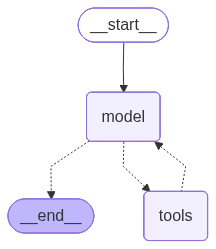

In [15]:
# ---------------------------------------------------
# Agentic RAG: 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent: create_agent가 생성한 에이전트로, 도구 호출 여부를 자율 결정해요
# tools: search_ai_brief(전체 검색)와 search_with_page_filter(페이지 범위 검색) 도구를 실행해요
# ReAct 패턴: 추론(agent) → 행동(tools) → 관찰(agent) 루프를 자동으로 수행해요
from IPython.display import Image, display
display(Image(agentic_rag_app.get_graph().draw_mermaid_png()))

In [16]:
# ---------------------------------------------------
# Agentic RAG: 실행 테스트
# ---------------------------------------------------
from langchain_core.messages import HumanMessage

agentic_config = RunnableConfig(
    recursion_limit=15,  # 에이전트는 여러 번 도구를 호출할 수 있어요
    configurable={"thread_id": str(uuid.uuid4())}
)

# 도구 사용이 필요한 질문
agentic_inputs = {
    "messages": [HumanMessage(content="삼성전자가 개발한 생성형 AI의 이름과 주요 특징을 설명해줘")]
}

# ============================================================
print(f"질문: {agentic_inputs['messages'][0].content}")
# ============================================================

# 스트리밍 실행
for chunk in agentic_rag_app.stream(agentic_inputs, agentic_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()

질문: 삼성전자가 개발한 생성형 AI의 이름과 주요 특징을 설명해줘

--- 노드: model ---
================================== Ai Message ==================================
Tool Calls:
  search_ai_brief (call_WzLqkFoF0IJUmMYcZ5FopMmY)
 Call ID: call_WzLqkFoF0IJUmMYcZ5FopMmY
  Args:
    query: 삼성전자 생성형 AI

--- 노드: tools ---
================================= Tool Message =================================
Name: search_ai_brief

<document>
<content>다양한 모델로 구성되며, 메일 작성, 문서 요약, 번역 업무의 처리를 지원∙코드 모델 기반의 AI 코딩 어시스턴트 ‘코드아이(code.i)’는 대화형 인터페이스로 서비스를 제공하며 사내 소프트웨어 개발에 최적화∙이미지 모델은 창의적인 이미지를 생성하고 기존 이미지를 원하는 대로 바꿀 수 있도록 지원하며 저해상도 이미지의 고해상도 전환도 지원nIT 전문지 테크리퍼블릭(TechRepublic)은 온디바이스 AI가 주요 기술 트렌드로 부상했다며, 2024년부터 가우스를 탑재한 삼성 스마트폰이 메타의 라마(Llama)2를 탑재한 퀄컴 기기 및 구글 어시스턴트를 적용한 구글 픽셀(Pixel)과 경쟁할 것으로 예상☞ 출처 : 삼성전자, ‘삼성 AI 포럼’서 자체 개발 생성형 AI ‘삼성 가우스’ 공개, 2023.11.08.삼성전자, ‘삼성 개발자 콘퍼런스 코리아 2023’ 개최, 2023.11.14.TechRepublic, Samsung Gauss: Samsung Research</content>
<source>data/SPRI_AI_Brief_2023년12월호_F.pdf</source>
<page>13</page>
</document>

<d

In [17]:
# ---------------------------------------------------
# Agentic RAG: 페이지 범위 필터링 도구 테스트
# ---------------------------------------------------
# 특정 페이지 범위 내에서만 검색하는 도구를 테스트해요
agentic_config2 = RunnableConfig(
    recursion_limit=15,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 특정 섹션(정책/법제)에 대한 질문
agentic_inputs2 = {
    "messages": [HumanMessage(
        content="문서의 앞부분(1-5페이지)에서 AI 관련 정책이나 법제 내용을 알려줘"
    )]
}

# ============================================================
print(f"질문: {agentic_inputs2['messages'][0].content}")
# ============================================================

for chunk in agentic_rag_app.stream(agentic_inputs2, agentic_config2, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()

질문: 문서의 앞부분(1-5페이지)에서 AI 관련 정책이나 법제 내용을 알려줘

--- 노드: model ---
================================== Ai Message ==================================
Tool Calls:
  search_with_page_filter (call_LUhWU4BK4MGDkoR97sufMoir)
 Call ID: call_LUhWU4BK4MGDkoR97sufMoir
  Args:
    query: 정책 법제
    start_page: 1
    end_page: 5

--- 노드: tools ---
================================= Tool Message =================================
Name: search_with_page_filter

<document>
<content>Ⅰ. 인공지능 산업 동향 브리프 1. 정책/법제    ▹ 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표  ·························1   ▹ G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의···························2   ▹ 영국 AI 안전성 정상회의에 참가한 28개국, AI 위험에 공동 대응 선언···························3   ▹ 미국 법원, 예술가들이 생성 AI 기업에 제기한 저작권 소송 기각·····································4   ▹ 미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 측면의 AI 의견서 제출·················5   ▹ EU AI 법 3자 협상, 기반모델 규제 관련 견해차로 난항···················································6  2. 기업/산업    ▹ 미국</content>
<source>data/SPRI_AI_Brief

---

## 5. 패턴 3: Hybrid RAG

**Hybrid RAG**는 **쿼리 강화(Query Enhancement)**와 **검증 루프(Validation Loop)**를 결합한 고급 패턴이에요. 단일 쿼리로 검색하는 대신, 원본 쿼리를 다양한 방식으로 확장하여 더 많은 관련 문서를 찾아요.

> 🔑 **핵심 개념**: Hybrid RAG는 **형사 수사**와 비슷해요. 단서 하나(원본 쿼리)로 수사하는 것보다, 같은 사건을 여러 각도에서 조사(강화된 쿼리들)하면 더 많은 증거(관련 문서)를 찾을 수 있어요. "삼성전자 AI"라는 하나의 질문을 "삼성 가우스", "삼성 생성형 AI 모델", "Samsung AI development" 등으로 다각화하면 놓치는 문서가 줄어들어요.

### Hybrid RAG의 핵심 아이디어

1. **쿼리 강화**: 원본 질문을 3-5개의 다양한 관점으로 재작성해요
2. **다중 검색**: 각 강화된 쿼리로 개별 검색 수행 (재현율 향상)
3. **중복 제거**: 동일 청크가 여러 번 검색되면 한 번만 사용해요
4. **검증**: 충분한 문서가 모였는지 확인, 아니면 재시도

### 쿼리 강화가 왜 효과적인가요?

| 원본 쿼리 | 강화된 쿼리 예시 | 새로 찾을 수 있는 정보 |
|----------|----------------|---------------------|
| "삼성전자 AI" | "삼성 가우스 생성형 AI 특징" | 삼성 가우스의 기술적 특징 |
| | "Samsung Electronics AI investment 2023" | 삼성의 AI 투자 관련 영문 정보 |
| | "삼성전자 AI 모델 출시 일정" | 모델 출시 타임라인 |

> 💡 **실무 팁**: 단일 쿼리로 검색할 때는 특정 단어가 포함된 문서만 찾을 수 있어요. 쿼리를 다각화하면 같은 주제를 다른 표현으로 담은 문서까지 포함할 수 있어요. 이것이 Hybrid RAG의 핵심이에요.

### Hybrid RAG 흐름

```mermaid
flowchart TD
    A([START]) --> B[enhance_query<br/>쿼리 강화]
    B --> C[multi_retrieve<br/>다중 검색 + 중복제거]
    C --> D{validate_results<br/>검증}
    D -- 불충분 --> B
    D -- 충분 --> E[generate<br/>답변 생성]
    E --> F([END])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef terminal fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A,F terminal
    class B,C process
    class D decision
    class E output
```

> ⚠️ **자주 하는 실수**: 검증 루프에서 `retry_count`를 관리하지 않으면 무한 루프가 발생할 수 있어요. `max_retries` 제한을 반드시 설정해요.

In [18]:
# ---------------------------------------------------
# Hybrid RAG: 쿼리 강화 체인 구성
# ---------------------------------------------------
# 원본 쿼리를 다양한 관점에서 재작성하는 LLM 체인이에요
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


# 강화된 쿼리 목록을 담는 Pydantic 모델
class EnhancedQueries(BaseModel):
    """원본 쿼리에서 파생된 강화된 검색 쿼리 목록이에요."""

    queries: List[str] = Field(
        description="다양한 관점에서 재작성된 검색 쿼리 목록 (3-5개)"
    )


# 쿼리 강화 프롬프트
ENHANCE_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a query enhancement specialist. Given an original search query,
generate 3-5 diverse variations that cover different aspects and phrasings of the same topic.
This helps retrieve more comprehensive information from the document.
Output only the query list, no explanations."""),
    ("human", "Original query: {question}\n\nGenerate enhanced queries:")
])

# 구조화된 출력으로 쿼리 목록을 안정적으로 파싱해요
enhance_chain = ENHANCE_PROMPT | llm.with_structured_output(EnhancedQueries)

# 테스트: 쿼리 강화 확인
test_enhanced = enhance_chain.invoke({"question": "삼성전자 AI 개발"})
# 원본 쿼리: 삼성전자 AI 개발
# 강화된 쿼리:
for i, q in enumerate(test_enhanced.queries, 1):
    print(f"  {i}. {q}")

  1. 삼성전자 인공지능 연구 현황
  2. 삼성전자 AI 기술 발전
  3. 삼성전자 AI 프로젝트 및 성과
  4. 삼성전자 인공지능 개발 전략
  5. 삼성전자 AI 관련 최신 뉴스


In [19]:
# ---------------------------------------------------
# Hybrid RAG: 상태(State) 정의
# ---------------------------------------------------

class HybridRAGState(TypedDict):
    """Hybrid RAG 그래프의 상태 정의예요."""

    question: Annotated[str, "원본 사용자 질문"]
    enhanced_queries: Annotated[List[str], "강화된 쿼리 목록"]
    documents: Annotated[List, "중복 제거된 검색 문서 리스트"]
    generation: Annotated[str, "생성된 최종 답변"]
    retry_count: Annotated[int, "검색 재시도 횟수"]  # 무한 루프 방지용

In [20]:
# ---------------------------------------------------
# Hybrid RAG: 노드 함수 정의
# ---------------------------------------------------

def enhance_query(state: HybridRAGState) -> HybridRAGState:
    """원본 쿼리를 다양한 관점으로 강화하는 노드예요."""
    # ==== [HYBRID RAG: ENHANCE QUERY] ====
    question = state["question"]
    retry_count = state.get("retry_count", 0)

    # 쿼리 강화 체인 실행
    enhanced = enhance_chain.invoke({"question": question})

    # 원본 쿼리도 포함하여 최종 쿼리 목록 생성
    all_queries = [question] + enhanced.queries
    print(f"  생성된 강화 쿼리 수: {len(all_queries)}개 (원본 포함)")
    for i, q in enumerate(all_queries):
        print(f"    {i+1}. {q}")

    return {
        "enhanced_queries": all_queries,
        "retry_count": retry_count + 1
    }


def multi_retrieve(state: HybridRAGState) -> HybridRAGState:
    """강화된 쿼리 각각으로 검색하고 중복을 제거하는 노드예요."""
    # ==== [HYBRID RAG: MULTI RETRIEVE] ====
    queries = state["enhanced_queries"]

    # 각 쿼리로 개별 검색 수행
    all_docs = []
    seen_ids = set()  # 중복 제거를 위한 ID 추적

    for query in queries:
        results = retriever.invoke(query)
        for doc in results:
            # 내용 기반 중복 제거 (같은 페이지의 같은 내용)
            doc_id = (doc.metadata.get("page", 0), doc.page_content[:100])
            if doc_id not in seen_ids:
                seen_ids.add(doc_id)
                all_docs.append(doc)

    print(f"  총 수집 문서 수: {len(all_docs)}개 (중복 제거 후)")
    return {"documents": all_docs}


def hybrid_generate(state: HybridRAGState) -> HybridRAGState:
    """수집된 모든 문서를 컨텍스트로 답변을 생성하는 노드예요."""
    # ==== [HYBRID RAG: GENERATE] ====
    question = state["question"]
    documents = state["documents"]

    context = format_docs(documents)
    generation = rag_chain.invoke({"context": context, "question": question})
    return {"generation": generation}

In [21]:
# ---------------------------------------------------
# Hybrid RAG: 검증 조건부 엣지
# ---------------------------------------------------
from typing import Literal

# 최소 필요 문서 수 (이 수 이상이면 생성 진행)
MIN_DOCS_REQUIRED = 3
# 최대 재시도 횟수 (무한 루프 방지)
MAX_RETRIES = 2


def validate_results(state: HybridRAGState) -> Literal["enhance_query", "generate"]:
    """검색 결과가 충분한지 검증하는 조건부 엣지예요.

    Returns:
        'enhance_query': 문서 부족 → 쿼리 강화 재시도
        'generate': 충분한 문서 수집 → 답변 생성
    """
    # ==== [HYBRID RAG: VALIDATE] ====
    documents = state.get("documents", [])
    retry_count = state.get("retry_count", 0)

    print(f"  수집된 문서 수: {len(documents)}, 재시도 횟수: {retry_count}")

    # 최대 재시도 초과 시 강제 생성
    if retry_count >= MAX_RETRIES:
        #   결정: 최대 재시도 도달 → 강제 생성
        return "generate"

    # 충분한 문서가 있으면 생성
    if len(documents) >= MIN_DOCS_REQUIRED:
        #   결정: 문서 충분 → 답변 생성
        return "generate"
    else:
        #   결정: 문서 부족 → 쿼리 강화 재시도
        return "enhance_query"

In [22]:
# ---------------------------------------------------
# Hybrid RAG: 그래프 조립 및 컴파일
# ---------------------------------------------------
from langgraph.checkpoint.memory import MemorySaver

# HybridRAGState 기반 그래프 초기화
hybrid_workflow = StateGraph(HybridRAGState)

# 노드 등록
hybrid_workflow.add_node("enhance_query", enhance_query)
hybrid_workflow.add_node("multi_retrieve", multi_retrieve)
hybrid_workflow.add_node("generate", hybrid_generate)

# 엣지 연결
hybrid_workflow.add_edge(START, "enhance_query")         # 시작 → 쿼리 강화
hybrid_workflow.add_edge("enhance_query", "multi_retrieve")  # 강화 → 다중 검색

# 검증 후 조건부 분기
hybrid_workflow.add_conditional_edges(
    "multi_retrieve",
    validate_results,
    {
        "enhance_query": "enhance_query",  # 문서 부족 → 재강화
        "generate": "generate",            # 충분 → 생성
    }
)

hybrid_workflow.add_edge("generate", END)

# 체크포인터로 루프 상태 추적
hybrid_app = hybrid_workflow.compile(checkpointer=MemorySaver())
# Hybrid RAG 그래프 컴파일 완료

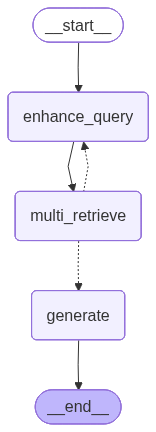

In [23]:
# ---------------------------------------------------
# Hybrid RAG: 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → enhance_query → multi_retrieve → (enhance_query | generate) → END
# enhance_query: 원본 질문을 3-5개의 다양한 관점으로 재작성해요
# multi_retrieve: 강화된 쿼리 각각으로 검색하고 중복을 제거해요
# validate_results: 문서가 충분하면 generate, 부족하면 enhance_query로 루프해요
# max_retries: 무한 루프 방지를 위해 재시도 횟수를 제한해요
# 쿼리 강화 → 다중 검색 → 검증 루프 구조를 확인해요
from IPython.display import Image, display
display(Image(hybrid_app.get_graph().draw_mermaid_png()))

In [24]:
# ---------------------------------------------------
# Hybrid RAG: 실행 테스트
# ---------------------------------------------------
hybrid_config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 복합적인 정보가 필요한 질문 (여러 문서 조각이 필요)
hybrid_inputs = {
    "question": "2023년 하반기 주요 AI 기업들의 투자 및 협력 동향을 정리해줘",
    "retry_count": 0  # 초기 재시도 횟수
}

# ============================================================
print(f"질문: {hybrid_inputs['question']}")
# ============================================================

# 스트리밍 실행
final_answer = None
for chunk in hybrid_app.stream(hybrid_inputs, hybrid_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "documents" in node_output:
            print(f"수집된 문서 수: {len(node_output['documents'])}개")
        if "generation" in node_output:
            final_answer = node_output["generation"]

if final_answer:
    # ============================================================
    # 최종 답변:
    print(final_answer)

질문: 2023년 하반기 주요 AI 기업들의 투자 및 협력 동향을 정리해줘
  생성된 강화 쿼리 수: 6개 (원본 포함)
    1. 2023년 하반기 주요 AI 기업들의 투자 및 협력 동향을 정리해줘
    2. 2023년 하반기 AI 기업들의 투자 현황과 협력 관계 분석
    3. 2023년 하반기 주요 인공지능 기업들의 파트너십 및 투자 트렌드
    4. 2023년 하반기 AI 산업에서의 주요 기업들의 협력 및 투자 동향
    5. 2023년 하반기 AI 기업들의 전략적 투자 및 협력 사례
    6. 2023년 하반기 인공지능 분야에서의 기업 투자 및 협력 현황

--- 노드: enhance_query ---
  총 수집 문서 수: 6개 (중복 제거 후)
  수집된 문서 수: 6, 재시도 횟수: 1

--- 노드: multi_retrieve ---
수집된 문서 수: 6개

--- 노드: generate ---
2023년 하반기 주요 AI 기업들의 투자 및 협력 동향은 다음과 같습니다:

1. **구글**: 앤스로픽에 20억 달러를 투자하여 생성 AI 협력을 강화하고, AI 동영상 제작 도구를 개발하는 런웨이와 오픈소스 소프트웨어 기업 허깅 페이스에도 투자하였습니다. 또한, 차세대 LLM '제미니'를 개발 중이며, 2024년 출시를 계획하고 있습니다 (출처: SPRi AI Brief, 2023년 12월호, 페이지 14).

2. **마이크로소프트**: 오픈AI에 대한 투자를 확대하여, 기존 30억 달러에 추가로 100억 달러를 투자하고 오픈AI의 지분 49%를 확보했습니다. 오픈AI는 마이크로소프트의 애저(Azure) 클라우드 플랫폼을 사용하여 AI 모델을 훈련하고 있습니다 (출처: SPRi AI Brief, 2023년 12월호, 페이지 14).

3. **삼성전자**: 자체 개발한 생성 AI '삼성 가우스'를 공개하였습니다 (출처: SPRi AI Brief, 2023년 12월호, 페이지 10).

4. **코히어**: 데이터 투명성을 확보하기 위한

---

## 6. 메타데이터 필터링

**메타데이터 필터링**은 검색 범위를 특정 소스, 날짜, 페이지 번호 등으로 제한하는 강력한 기법이에요. 특히 다중 문서를 인덱싱할 때 특정 문서에서만 검색하고 싶을 때 유용해요.

> 🎯 **강의 포인트**: 메타데이터 필터링은 프로덕션 RAG 시스템에서 매우 중요한 기법이에요. 여러 고객사의 문서를 한 인덱스에 저장하고, 각 고객의 질문은 해당 고객의 문서에서만 검색하도록 격리할 수 있어요.

In [25]:
# ---------------------------------------------------
# 메타데이터 필터링 예시
# ---------------------------------------------------
# FAISS에서 메타데이터 필터링은 filter 파라미터를 사용해요
# 주의: FAISS는 exact match 필터링만 지원해요 (범위 검색은 직접 구현 필요)

# 방법 1: as_retriever에서 filter 직접 지정
# 특정 페이지(0-based)의 문서만 검색해요
filtered_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 4,
        "filter": {"page": 9}  # page 메타데이터가 9인 문서만 검색 (10페이지, 0-based)
    }
)

# 필터링 검색 테스트
filtered_results = filtered_retriever.invoke("AI 기업")
print(f"필터링 검색 결과: {len(filtered_results)}개")
for doc in filtered_results:
    print(f"  페이지: {doc.metadata.get('page', 0) + 1}, 내용: {doc.page_content[:80]}...")

필터링 검색 결과: 0개


In [26]:
# ---------------------------------------------------
# 페이지 범위 필터링 (직접 구현)
# ---------------------------------------------------
# FAISS는 범위 필터를 직접 지원하지 않아서 후처리로 구현해요


def search_with_page_range(query: str, start_page: int, end_page: int, k: int = 4):
    """특정 페이지 범위에서만 검색해요.

    Args:
        query: 검색 쿼리
        start_page: 시작 페이지 (1-based)
        end_page: 끝 페이지 (1-based, 포함)
        k: 반환할 최대 문서 수

    Returns:
        필터링된 Document 리스트
    """
    # 더 많이 검색해서 필터링 후 k개를 맞춰요
    all_results = vectorstore.similarity_search(query, k=k * 5)

    # 페이지 범위 필터 (page는 0-based이므로 변환 필요)
    filtered = [
        doc for doc in all_results
        if start_page - 1 <= doc.metadata.get("page", 0) <= end_page - 1
    ]

    return filtered[:k]


# 테스트: 정책/법제 섹션(1-6페이지)에서만 검색
policy_results = search_with_page_range("AI 규제 법안", start_page=1, end_page=6)
print(f"정책 섹션(1-6페이지) 검색 결과: {len(policy_results)}개")
for doc in policy_results:
    print(f"  페이지: {doc.metadata.get('page', 0) + 1}, 내용: {doc.page_content[:100]}...")

정책 섹션(1-6페이지) 검색 결과: 4개
  페이지: 2, 내용: Ⅰ. 인공지능 산업 동향 브리프 1. 정책/법제    ▹ 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표  ·························1 ...
  페이지: 4, 내용: 1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 n미국 바이든 대통령이 ‘안전하고 신뢰할 ...
  페이지: 4, 내용: 주로 사용하고 1023플롭스를 초과하는 컴퓨팅 성능을 사용하는 모델 △단일 데이터센터에서 1,000Gbit/s 이상의 네트워킹으로 연결되며 AI 훈련에서 이론상 최대 1020 플롭...
  페이지: 5, 내용: 행동강령을 통해 아래의 조치를 제시했으며, 빠르게 발전하는 기술에 대응할 수 있도록 이해관계자 협의를 통해 필요에 따라 개정할 예정∙첨단 AI 시스템의 개발 과정에서 AI 수명주기...


---

## 7. 세 패턴 비교 실험

> 🎯 **강의 포인트**: 동일한 질문으로 세 패턴을 비교하면서 각각의 특성을 직접 확인해볼게요. 속도, 정확도, 컨텍스트 풍부함에서 차이가 나는 것을 확인해요.

In [27]:
# ============================================================
# 실습 해설: 세 패턴 비교 실험
# 힌트: 아래 질문을 변경하거나 자신만의 질문을 추가해요
#       각 패턴이 어떻게 다른 답변을 생성하는지 비교해요
# 예상 결과:
#   - 2-Step: 가장 빠르지만 단일 쿼리 한계
#   - Agentic: 필요할 때만 검색, 유연함
#   - Hybrid: 가장 많은 컨텍스트, 다소 느림
# ============================================================

# 비교할 질문 (변경해보세요!)
comparison_question = "2023년 하반기 주요 AI 회사들의 동향은?"

import time

print(f"비교 질문: {comparison_question}")
# ======================================================================

# --- 2-Step RAG ---
start = time.time()
twostep_result = twostep_app.invoke(
    {"question": comparison_question},
    RunnableConfig(configurable={"thread_id": str(uuid.uuid4())})
)
twostep_time = time.time() - start

print(f"\n[1] 2-Step RAG ({twostep_time:.1f}초)")
# ----------------------------------------
print(twostep_result.get("generation", "N/A"))

# --- Hybrid RAG ---
start = time.time()
hybrid_result = hybrid_app.invoke(
    {"question": comparison_question, "retry_count": 0},
    RunnableConfig(
        recursion_limit=20,
        configurable={"thread_id": str(uuid.uuid4())}
    )
)
hybrid_time = time.time() - start

print(f"\n[3] Hybrid RAG ({hybrid_time:.1f}초)")
# ----------------------------------------
print(hybrid_result.get("generation", "N/A"))

비교 질문: 2023년 하반기 주요 AI 회사들의 동향은?
  검색된 문서 수: 4개

[1] 2-Step RAG (4.5초)
2023년 하반기 주요 AI 회사들의 동향은 다음과 같습니다:

1. **미국 프런티어 모델 포럼**: 1,000만 달러 규모의 AI 안전 기금을 조성하였습니다 (페이지 2).
2. **코히어**: 데이터 투명성을 확보하기 위한 데이터 출처 탐색기를 공개하였습니다 (페이지 2).
3. **알리바바 클라우드**: 최신 LLM인 '통이치엔원 2.0'을 공개하였습니다 (페이지 2).
4. **삼성전자**: 자체 개발한 생성 AI '삼성 가우스'를 공개하였습니다 (페이지 2).
5. **구글**: 앤스로픽에 20억 달러를 투자하여 생성 AI 협력을 강화하였습니다 (페이지 2).

이 외에도 IDC는 AI 소프트웨어 시장이 2027년까지 2,500억 달러를 돌파할 것이라고 전망하고 있으며, AI 애플리케이션이 전체 매출의 약 3분의 1을 차지할 것으로 예상하고 있습니다 (페이지 15).
  생성된 강화 쿼리 수: 6개 (원본 포함)
    1. 2023년 하반기 주요 AI 회사들의 동향은?
    2. 2023년 하반기 AI 기업들의 주요 변화와 발전은 무엇인가?
    3. 올해 하반기 AI 산업에서 두드러진 회사들의 활동은 어떤 것들이 있는가?
    4. 2023년 하반기 동안의 주요 인공지능 기업 동향 분석
    5. 하반기 AI 회사들의 전략과 혁신적인 프로젝트는 무엇인가?
    6. 2023년 하반기 AI 관련 기업들의 시장 동향과 경쟁 상황은 어떻게 변화하고 있는가?
  총 수집 문서 수: 9개 (중복 제거 후)
  수집된 문서 수: 9, 재시도 횟수: 1

[3] Hybrid RAG (8.7초)
2023년 하반기 주요 AI 회사들의 동향은 다음과 같습니다:

1. **미국 프런티어 모델 포럼**: 1,000만 달러 규모의 AI 안전 기금을 조성하였습니다 (페이지 2).
   
2. **코히어**: 데이터 투명성을 확보하기 위한

---

## 8. MMR 검색: 다양성 보장 검색

**MMR(Maximal Marginal Relevance)**는 관련성과 다양성을 동시에 고려하는 검색 방법이에요. 유사한 내용의 문서가 반복 선택되는 것을 방지해요.

> 🔑 **핵심 개념**: 일반 유사도 검색은 "가장 비슷한 문서 4개"를 찾아요. 하지만 같은 문단에서 잘린 청크 3개가 선택되면 **사실상 같은 내용을 3번 보는 꼴**이에요. MMR은 **뉴스 큐레이션**처럼 동작해요 — 같은 사건의 기사 10개가 있을 때, 서로 다른 관점의 기사 4개를 골라주는 거예요.

### 유사도 검색 vs MMR 비교

| 항목 | 유사도 검색 (similarity) | MMR 검색 |
|------|------------------------|----------|
| 기준 | 관련성만 고려 | 관련성 + 다양성 동시 고려 |
| 장점 | 가장 관련 높은 문서 보장 | 다양한 관점의 문서 수집 |
| 단점 | 중복 청크 가능 | 관련성이 약간 낮을 수 있음 |
| `lambda_mult` | 해당 없음 | 0=최대 다양성, 1=최대 관련성 |

> 💡 **실무 팁**: 긴 문서에서 같은 섹션의 청크가 반복적으로 선택될 때 MMR이 효과적이에요. `lambda_mult` 파라미터로 관련성(1.0)과 다양성(0.0) 사이의 균형을 조절해요. 일반적으로 `0.5`가 좋은 출발점이에요.

In [28]:
# ---------------------------------------------------
# MMR 검색 비교
# ---------------------------------------------------
# MMR: Maximal Marginal Relevance
# 관련성이 높으면서도 서로 다른 내용의 문서를 선택해요

# 일반 유사도 검색
similarity_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

# MMR 검색
# lambda_mult: 0 = 최대 다양성, 1 = 최대 관련성 (기본값 0.5)
# fetch_k: 후보 문서 수 (이 중에서 k개를 MMR로 선택)
mmr_retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 4,
        "fetch_k": 20,     # 후보 20개 중에서 4개를 MMR로 선택해요
        "lambda_mult": 0.5  # 관련성과 다양성의 균형
    }
)

# 비교 테스트
test_q = "AI 기업 투자"

sim_results = similarity_retriever.invoke(test_q)
mmr_results = mmr_retriever.invoke(test_q)

print(f"검색어: '{test_q}'")
# [유사도 검색] 결과 페이지:
print([f"p.{doc.metadata.get('page', 0)+1}" for doc in sim_results])

# [MMR 검색] 결과 페이지:
print([f"p.{doc.metadata.get('page', 0)+1}" for doc in mmr_results])

# → MMR은 같은 페이지 문서가 중복 선택되는 것을 줄여요

검색어: 'AI 기업 투자'
['p.2', 'p.15', 'p.14', 'p.3']
['p.2', 'p.3', 'p.14', 'p.8']


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **2-Step RAG**: 검색 → 생성의 선형 파이프라인. 단순하고 빠르며 디버깅이 쉬워요. `TypedDict` 상태에 `question`, `documents`, `generation`을 정의해요.
- **FAISS + as_retriever()**: `search_type`(similarity/mmr)과 `search_kwargs`(k, fetch_k, filter)로 검색 동작을 세밀하게 조정해요.
- **Agentic RAG**: `create_agent` + `@tool` 데코레이터로 에이전트가 검색 도구 사용 여부를 자율 결정해요. docstring이 도구 선택의 핵심이에요.
- **Hybrid RAG**: 쿼리 강화(Query Enhancement)로 N개의 다양한 쿼리를 생성하고, 중복 제거 후 더 많은 관련 문서를 수집해요. 검증 루프로 품질을 보장하되 `max_retries`로 무한 루프를 방지해요.
- **메타데이터 필터링**: `filter` 파라미터로 특정 페이지/소스 범위에서만 검색을 제한해요. 다중 문서 시스템에서 필수적인 기법이에요.
- **MMR 검색**: `search_type="mmr"`로 관련성과 다양성을 동시에 고려하여 중복된 청크 선택을 줄여요.

## 다음 노트북 예고

지금까지의 RAG 그레이더들은 모두 'yes/no' **이진 판단**이었어요. 하지만 "관련은 있는데 60%만 충분하다"처럼 애매한 경우, 이진 그레이더는 정보를 버릴 수밖에 없어요. 다음 노트북 **`06-Score-Based-Critic.ipynb`**에서는 groundedness·relevance·completeness 3축을 **0~1 점수**로 평가하는 Critic을 만들고, 임계값(PASS_THRESHOLD)과 반복 한도(MAX_ITERATIONS)로 품질-비용을 제어하는 **점수 기반 자기 교정 루프**를 구현해요. 이어지는 **`07-Memory-Augmented-RAG.ipynb`**에서는 Store API 장기기억을 RAG 그래프에 통합하는 Part 08 캡스톤으로 마무리해요.
